# Customer Retention & Cohort Analysis

## Executive Summary

This project analyzes ecommerce customer retention using cohort analysis, repeat purchase behavior, and customer segmentation.

The main finding is that retention drops sharply after the first purchase, suggesting the strongest growth opportunity is improving second-purchase conversion rather than focusing only on long-term loyalty.

## Objective
Analyze customer purchasing behavior to measure **retention, repeat purchase patterns, and cohort performance** using transactional ecommerce data.

This project reflects a practical analytics workflow:
- transforming raw transaction data into business-ready datasets
- defining customer cohorts
- measuring retention over time
- comparing behavior across customer segments
- translating findings into business actions

---

## Business Context
In ecommerce, retention is a core driver of:
- revenue stability
- customer lifetime value (LTV)
- marketing efficiency
- long-term growth quality

Key business questions:
- What share of customers return after their first purchase?
- How quickly does retention decline over time?
- Do higher-value customers retain better than lower-value customers?
- Where is the strongest opportunity to improve lifecycle performance?

---

## Dataset
**Online Retail** transactional dataset (UCI)

Scope used in this project:
- product description
- quantity
- invoice timestamp
- unit price
- customer ID
- country

---

## Analytical Workflow

### 1. Data preparation
- clean invalid transactions
- create revenue metric
- optimize memory usage

### 2. Customer segmentation
- calculate total customer revenue
- segment customers into low / mid / high value groups

### 3. Order-level modeling
- define order as `customerid + invoicedate`
- aggregate transaction rows into order-level events

### 4. Cohort construction
- assign each customer to a first-purchase month
- calculate lifecycle month index

### 5. Retention analysis
- build retention matrix
- visualize retention by cohort
- compare repeat behavior across segments

---

## Tools
- Python (`pandas`)
- Matplotlib / Seaborn
- SQL (logic translation)

---

## Output
- retention matrix
- cohort heatmap
- repeat customer KPI
- segment-level retention comparison
- business recommendations

This type of analysis is directly relevant to:
- Product Analytics
- Marketing Analytics
- Ecommerce Analytics
- Customer Lifecycle Analytics

In [47]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
DATA_URLS = [
    "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx",
    "https://raw.githubusercontent.com/nelsoncardenas/Customer-segmentation-on-Online-Retail-Data-Set/main/Online%20Retail.xlsx"
]

usecols = ['Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

df = None
last_error = None

for url in DATA_URLS:
    try:
        df = pd.read_excel(
            url,
            usecols=usecols,
            dtype={
                'Description': 'string',
                'Quantity': 'float32',
                'UnitPrice': 'float32',
                'CustomerID': 'float64',
                'Country': 'string'
            },
            parse_dates=['InvoiceDate'],
            engine='openpyxl'
        )
        print(f"Loaded successfully from: {url}")
        break
    except Exception as e:
        last_error = e
        print(f"Failed: {url}")
        print(e)

if df is None:
    raise ValueError(f"All load attempts failed. Last error: {last_error}")

df.columns = df.columns.str.strip().str.lower()

df = df[['description', 'quantity', 'invoicedate', 'unitprice', 'customerid', 'country']]

print(df.shape)
df.head()

Failed: https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx
HTTP Error 502: Bad Gateway
Loaded successfully from: https://raw.githubusercontent.com/nelsoncardenas/Customer-segmentation-on-Online-Retail-Data-Set/main/Online%20Retail.xlsx
(541909, 6)


,description,quantity,invoicedate,unitprice,customerid,country
0,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [48]:
clean = df.copy()

clean = clean.dropna(subset=['customerid'])

clean['customerid'] = clean['customerid'].astype('int32')

clean = clean[
    (clean['quantity'] > 0) &
    (clean['unitprice'] > 0)
].copy()

clean['quantity'] = clean['quantity'].astype('int32')
clean['unitprice'] = clean['unitprice'].astype('float32')

clean['line_revenue'] = (clean['quantity'] * clean['unitprice']).astype('float32')

clean['description'] = clean['description'].fillna('').str.strip()

print(clean.shape)
clean.head()

(397884, 7)


,description,quantity,invoicedate,unitprice,customerid,country,line_revenue
0,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.299999
1,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.340000
2,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.000000
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.340000
4,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.340000


In [49]:
customer_revenue = (
    clean.groupby('customerid', as_index=False)
    .agg(total_revenue=('line_revenue', 'sum'))
)

customer_revenue['segment'] = pd.qcut(
    customer_revenue['total_revenue'],
    q=3,
    labels=['low', 'mid', 'high'],
    duplicates='drop'
)

customer_revenue.head()

,customerid,total_revenue,segment
0,12346,77183.593750,high
1,12347,4310.000000,high
2,12348,1797.239990,high
3,12349,1757.550049,high
4,12350,334.399994,low


In [50]:
if 'segment' in clean.columns:
    clean = clean.drop(columns=['segment'])

clean = clean.merge(
    customer_revenue[['customerid', 'segment']],
    on='customerid',
    how='left'
)

print(clean.columns.tolist())
clean[['customerid', 'line_revenue', 'segment']].head()

['description', 'quantity', 'invoicedate', 'unitprice', 'customerid', 'country', 'line_revenue', 'segment']


,customerid,line_revenue,segment
0,17850,15.299999,high
1,17850,20.340000,high
2,17850,22.000000,high
3,17850,20.340000,high
4,17850,20.340000,high


In [51]:
orders = (
    clean
    .groupby(['customerid', 'invoicedate', 'segment'], observed=True)
    .agg(
        order_revenue=('line_revenue', 'sum'),
        items=('quantity', 'sum')
    )
    .reset_index()
)

orders['order_month'] = orders['invoicedate'].values.astype('datetime64[M]')

print("Orders created:", len(orders))
orders.head()

Orders created: 18440


,customerid,invoicedate,segment,order_revenue,items,order_month
0,12346,2011-01-18 10:01:00,high,77183.593750,74215,2011-01-01
1,12347,2010-12-07 14:57:00,high,711.789978,319,2010-12-01
2,12347,2011-01-26 14:30:00,high,475.390015,315,2011-01-01
3,12347,2011-04-07 10:43:00,high,636.250000,483,2011-04-01
4,12347,2011-06-09 13:01:00,high,382.519989,196,2011-06-01


In [52]:
print("Transactions:", len(clean))
print("Customers:", clean['customerid'].nunique())
print("Orders:", len(orders))

orders[['customerid', 'invoicedate', 'order_month', 'order_revenue', 'items', 'segment']].head()

Transactions: 397884
Customers: 4338
Orders: 18440


,customerid,invoicedate,order_month,order_revenue,items,segment
0,12346,2011-01-18 10:01:00,2011-01-01,77183.593750,74215,high
1,12347,2010-12-07 14:57:00,2010-12-01,711.789978,319,high
2,12347,2011-01-26 14:30:00,2011-01-01,475.390015,315,high
3,12347,2011-04-07 10:43:00,2011-04-01,636.250000,483,high
4,12347,2011-06-09 13:01:00,2011-06-01,382.519989,196,high


# Customer Retention & Cohort Analysis

## Executive Summary
This project evaluates customer retention using cohort analysis, repeat purchase behavior, and revenue-based segmentation.

The analysis shows that customer drop-off is strongest immediately after the first purchase, indicating that improving early lifecycle conversion is the clearest opportunity to increase retention and lifetime value.


## Cohort Construction

To evaluate retention accurately, customers are grouped by the month of their first purchase.

This allows retention to be measured from a common starting point and makes it possible to compare customer behavior across acquisition periods.

Key fields:
- cohort_month: first purchase month
- order_month: activity month
- cohort_index: months since first purchase

In [53]:

cohort_data = orders[['customerid', 'order_month', 'segment']].copy()

first_purchase = (
    cohort_data
    .groupby('customerid', as_index=False)
    .agg(cohort_month=('order_month', 'min'))
)

cohort_data = cohort_data.merge(
    first_purchase,
    on='customerid',
    how='left'
)

cohort_data['cohort_index'] = (
    (cohort_data['order_month'].dt.year - cohort_data['cohort_month'].dt.year) * 12
    + (cohort_data['order_month'].dt.month - cohort_data['cohort_month'].dt.month)
) + 1

print(cohort_data.shape)
cohort_data.head()

(18440, 5)


,customerid,order_month,segment,cohort_month,cohort_index
0,12346,2011-01-01,high,2011-01-01,1
1,12347,2010-12-01,high,2010-12-01,1
2,12347,2011-01-01,high,2010-12-01,2
3,12347,2011-04-01,high,2010-12-01,5
4,12347,2011-06-01,high,2010-12-01,7


## Retention Measurement Framework

After cohorts are defined, retention is measured as:

**active customers in a given lifecycle month / total customers in the cohort**

### Calculation steps
1. Count unique customers by cohort and lifecycle month
2. Pivot counts into a matrix
3. Convert counts into percentages

### Output
- cohort counts
- retention matrix
- retention heatmap

In [54]:
cohort_counts = (
    cohort_data
    .groupby(['cohort_month', 'cohort_index'], as_index=False)
    .agg(customers=('customerid', 'nunique'))
)

cohort_counts.head(10)

,cohort_month,cohort_index,customers
0,2010-12-01,1,885
1,2010-12-01,2,324
2,2010-12-01,3,286
3,2010-12-01,4,340
4,2010-12-01,5,321
5,2010-12-01,6,352
6,2010-12-01,7,321
7,2010-12-01,8,309
8,2010-12-01,9,313
9,2010-12-01,10,350


In [55]:
retention_counts = cohort_counts.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customers'
)

retention_counts.head()

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13
cohort_month,,,,,,,,,,,,,
2010-12-01,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02-01,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03-01,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04-01,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN


In [56]:
retention_pct = retention_counts.divide(retention_counts[1], axis=0) * 100
retention_pct = retention_pct.round(1)

retention_pct.head()

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13
cohort_month,,,,,,,,,,,,,
2010-12-01,100.0,36.6,32.3,38.4,36.3,39.8,36.3,34.9,35.4,39.5,37.4,50.3,26.6
2011-01-01,100.0,22.1,26.6,23.0,32.1,28.8,24.7,24.2,30.0,32.6,36.5,11.8,NaN
2011-02-01,100.0,18.7,18.7,28.4,27.1,24.7,25.3,27.9,24.7,30.5,6.8,NaN,NaN
2011-03-01,100.0,15.0,25.2,19.9,22.3,16.8,26.8,23.0,27.9,8.6,NaN,NaN,NaN
2011-04-01,100.0,21.3,20.3,21.0,19.7,22.7,21.7,26.0,7.3,NaN,NaN,NaN,NaN


## Cohort Retention Analysis

This chart evaluates how quickly customers return after acquisition and whether retention patterns differ across cohorts.

The main business use of this view is to identify whether retention weakness happens early in the lifecycle or later, and whether specific acquisition periods performed better or worse than others.

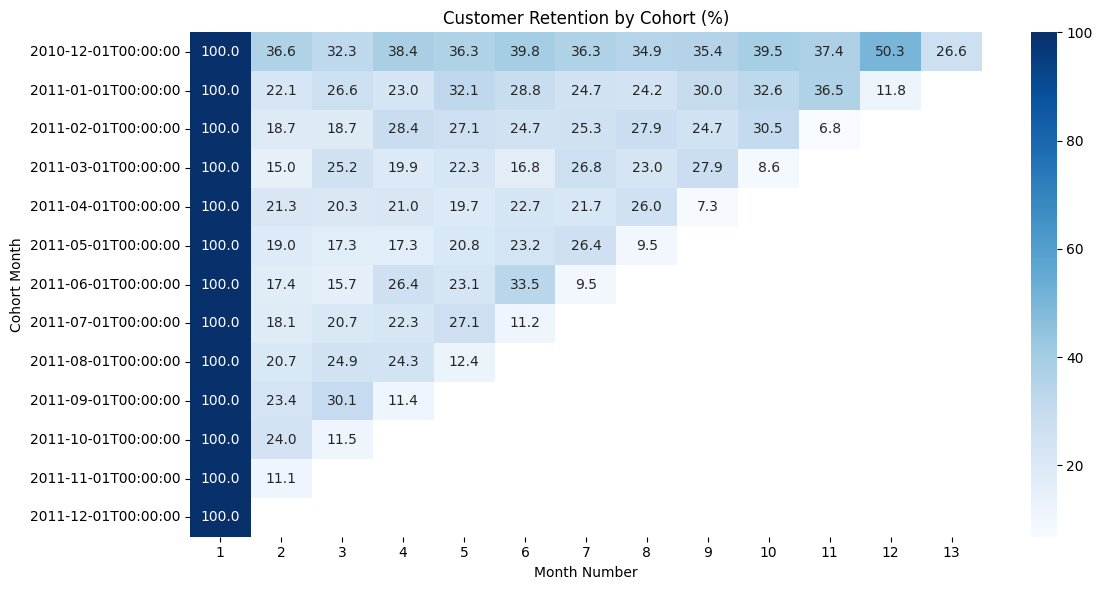

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(retention_pct, annot=True, fmt='.1f', cmap='Blues')
plt.title('Customer Retention by Cohort (%)')
plt.xlabel('Month Number')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()

## Repeat Purchase Behavior (Core KPI)

While cohort analysis explains **when** customers return, stakeholders also need a simple top-line retention measure that can be tracked in dashboards and business reviews.

**Repeat Customer Rate** answers that need.

### Metric Definition
Share of customers who placed more than one order during the observed period.

### Business Use
This KPI is useful for evaluating whether growth is supported by:
- recurring customer behavior
- or continued dependence on new customer acquisition

### Why it matters
- gives a quick signal of customer loyalty
- is easy to communicate to non-technical stakeholders
- works well in executive summaries and retention reporting

### How to interpret
- **Low repeat rate**  
  suggests the business relies heavily on one-time buyers, which can limit LTV and increase dependence on acquisition spend

- **High repeat rate**  
  suggests stronger customer stickiness, healthier repeat demand, and better long-term revenue quality

### Important limitation
This metric shows **whether** customers returned, but not **when** they returned.

For that reason, it should be interpreted together with cohort analysis rather than used as a standalone retention view.

In [58]:
customer_orders = (
    orders
    .groupby('customerid', as_index=False)
    .agg(order_count=('invoicedate', 'count'))
)

repeat_summary = (
    customer_orders
    .assign(is_repeat=customer_orders['order_count'] > 1)
    .groupby('is_repeat', as_index=False)
    .agg(customers=('customerid', 'count'))
)

total_customers = repeat_summary['customers'].sum()
repeat_customers = repeat_summary.loc[repeat_summary['is_repeat'], 'customers'].sum()
repeat_share = round(repeat_customers / total_customers * 100, 1)

print("Repeat customers:", repeat_customers)
print("Total customers:", total_customers)
print("Repeat customer share (%):", repeat_share)

Repeat customers: 2843
Total customers: 4338
Repeat customer share (%): 65.5


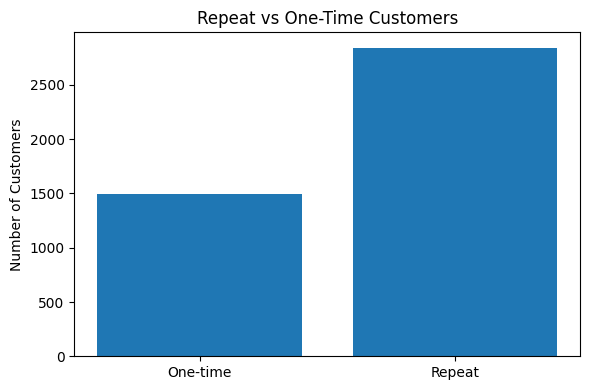

In [59]:
repeat_plot = repeat_summary.copy()
repeat_plot['label'] = repeat_plot['is_repeat'].map({True: 'Repeat', False: 'One-time'})

plt.figure(figsize=(6, 4))
plt.bar(repeat_plot['label'], repeat_plot['customers'])
plt.title('Repeat vs One-Time Customers')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

## Retention by Customer Segment

This view compares repeat behavior across low-, mid-, and high-value customers.

The goal is to understand whether higher-value customers also show stronger loyalty, which helps prioritize retention strategy and marketing effort.

In [60]:
customer_segment_orders = (
    orders
    .groupby(['customerid', 'segment'], observed=True)
    .agg(order_count=('invoicedate', 'count'))
    .reset_index()
)

segment_repeat = (
    customer_segment_orders
    .assign(is_repeat=lambda x: x['order_count'] > 1)
    .groupby('segment', observed=True)
    .agg(
        customers=('customerid', 'count'),
        repeat_customers=('is_repeat', 'sum')
    )
    .reset_index()
)

segment_repeat['repeat_rate_pct'] = (
    segment_repeat['repeat_customers'] / segment_repeat['customers'] * 100
).round(1)

segment_repeat

,segment,customers,repeat_customers,repeat_rate_pct
0,low,1446,360,24.9
1,mid,1446,1089,75.3
2,high,1446,1394,96.4


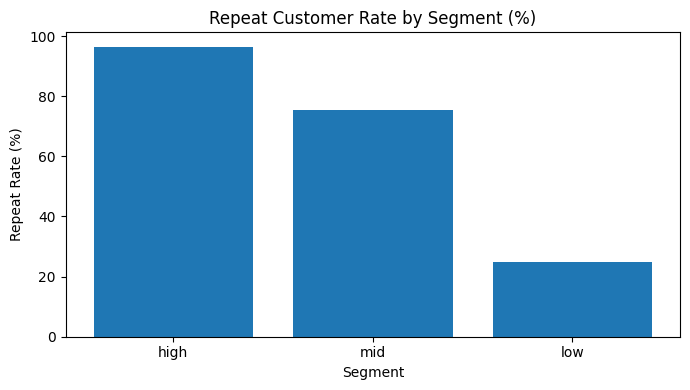

In [61]:
segment_repeat = segment_repeat.sort_values('repeat_rate_pct', ascending=False)

plt.figure(figsize=(7, 4))
plt.bar(segment_repeat['segment'], segment_repeat['repeat_rate_pct'])
plt.title('Repeat Customer Rate by Segment (%)')
plt.ylabel('Repeat Rate (%)')
plt.xlabel('Segment')
plt.tight_layout()
plt.show()

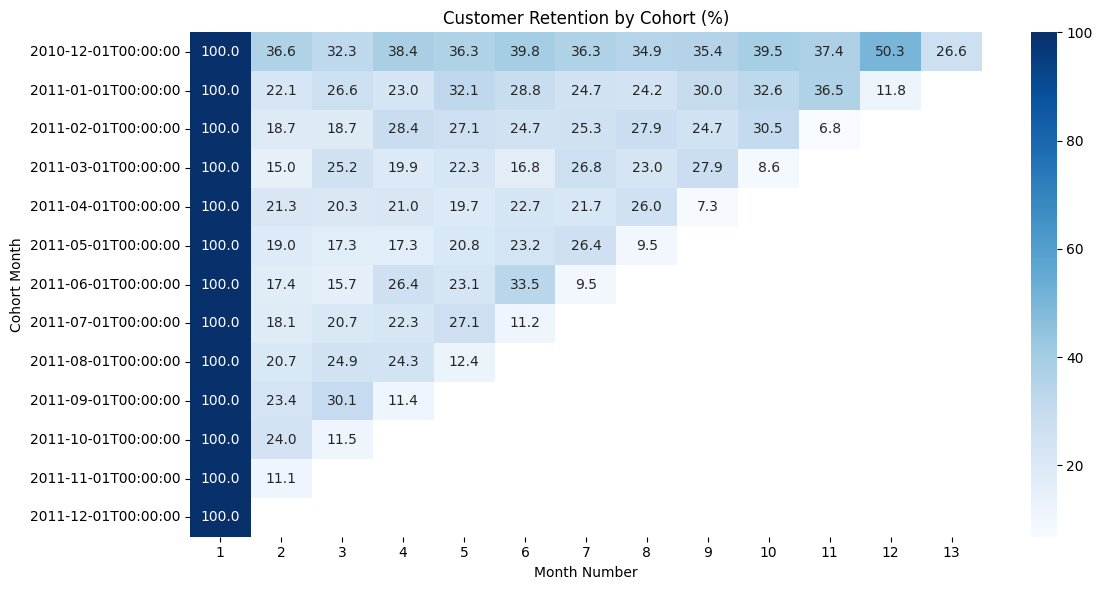

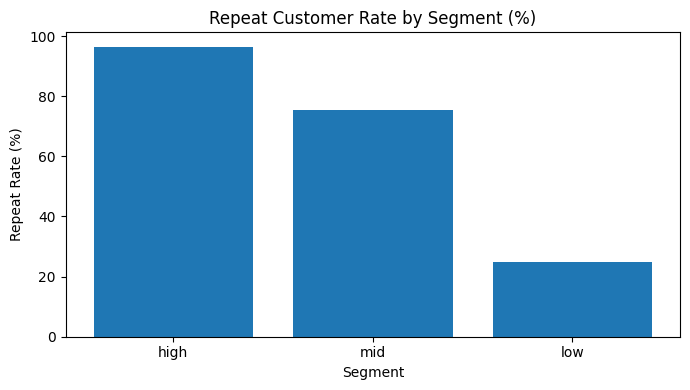

Saved files:
- retention_heatmap.png
- segment_repeat_rate.png


In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Retention heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(retention_pct, annot=True, fmt='.1f', cmap='Blues')
plt.title('Customer Retention by Cohort (%)')
plt.xlabel('Month Number')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.savefig("retention_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

# 2. Segment repeat rate bar chart
segment_plot = segment_repeat.sort_values('repeat_rate_pct', ascending=False).copy()

plt.figure(figsize=(7, 4))
plt.bar(segment_plot['segment'], segment_plot['repeat_rate_pct'])
plt.title('Repeat Customer Rate by Segment (%)')
plt.xlabel('Segment')
plt.ylabel('Repeat Rate (%)')
plt.tight_layout()
plt.savefig("segment_repeat_rate.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved files:")
print("- retention_heatmap.png")
print("- segment_repeat_rate.png")

## Management Summary

The analysis suggests that retention is primarily constrained by weak early repeat behavior rather than gradual long-term decay.

From a business perspective, this means the most valuable interventions are likely to be:
- improving the first post-purchase experience
- increasing second-purchase conversion
- prioritizing high-value customers with targeted retention efforts

## Key Business Insights

### 1. Early retention is the primary bottleneck
Retention declines sharply after the first purchase.

**Interpretation**
- many customers do not convert into repeat buyers
- the biggest opportunity is early lifecycle improvement, especially first-to-second purchase conversion

**Business action**
- strengthen post-purchase engagement
- improve onboarding and first-order experience
- test offers or reminders shortly after first purchase

---

### 2. Repeat customer rate highlights dependence on one-time buyers
A large one-time customer base suggests growth is driven more by acquisition than by loyalty.

**Risk**
- lower LTV
- weaker revenue efficiency
- heavier dependence on ongoing marketing spend

**Business action**
- track repeat customer rate as a core KPI
- prioritize programs that increase second purchase rate

---

### 3. Returning customers appear more stable after the initial drop
Once customers make a repeat purchase, retention behavior typically becomes more durable.

**Interpretation**
- there is likely a smaller loyal customer base
- early conversion into repeat behavior is the critical filter

**Business action**
- identify repeat buyers early
- target them with loyalty and CRM programs

---

### 4. Segment differences reveal where retention matters most
Higher-value customers likely have disproportionate impact on revenue.

**Interpretation**
- segment-level retention is more actionable than overall averages
- protecting high-value customer retention can have outsized business value

**Business action**
- create differentiated retention strategies by segment
- prioritize high-value cohorts for personalization and lifecycle campaigns

---

### 5. Cohort analysis reveals patterns hidden by aggregate metrics
Overall repeat rates are useful, but they can mask differences between acquisition periods.

**Interpretation**
- customer quality may vary across months
- seasonality or campaign timing may influence downstream retention

**Business action**
- use cohort-based reporting in addition to topline KPIs
- avoid relying on overall averages alone

---

## Final Takeaway
The strongest growth opportunity is likely **improving early-stage retention**.

Even modest gains in second-purchase conversion can improve:
- customer lifetime value
- marketing efficiency
- long-term revenue quality

In [63]:
# Cell 32: SQL equivalent

sql_query = """
WITH base AS (
    SELECT
        customerid,
        invoicedate,
        quantity,
        unitprice,
        quantity * unitprice AS line_revenue
    FROM online_retail
    WHERE customerid IS NOT NULL
      AND quantity > 0
      AND unitprice > 0
),

customer_revenue AS (
    SELECT
        customerid,
        SUM(line_revenue) AS total_revenue
    FROM base
    GROUP BY customerid
),

segmented AS (
    SELECT
        customerid,
        total_revenue,
        NTILE(3) OVER (ORDER BY total_revenue) AS segment_num
    FROM customer_revenue
),

orders AS (
    SELECT
        b.customerid,
        b.invoicedate,
        CASE
            WHEN s.segment_num = 1 THEN 'low'
            WHEN s.segment_num = 2 THEN 'mid'
            WHEN s.segment_num = 3 THEN 'high'
        END AS segment,
        SUM(b.line_revenue) AS order_revenue,
        SUM(b.quantity) AS items,
        DATE_TRUNC('month', b.invoicedate) AS order_month
    FROM base b
    LEFT JOIN segmented s
        ON b.customerid = s.customerid
    GROUP BY b.customerid, b.invoicedate, segment, order_month
),

cohorts AS (
    SELECT
        customerid,
        order_month,
        segment,
        MIN(order_month) OVER (PARTITION BY customerid) AS cohort_month
    FROM orders
),

cohort_final AS (
    SELECT
        customerid,
        cohort_month,
        order_month,
        segment,
        (
            EXTRACT(YEAR FROM AGE(order_month, cohort_month)) * 12
            + EXTRACT(MONTH FROM AGE(order_month, cohort_month))
            + 1
        ) AS cohort_index
    FROM cohorts
)

SELECT
    cohort_month,
    cohort_index,
    COUNT(DISTINCT customerid) AS retained_customers
FROM cohort_final
GROUP BY cohort_month, cohort_index
ORDER BY cohort_month, cohort_index;
"""

print(sql_query)


WITH base AS (
    SELECT
        customerid,
        invoicedate,
        quantity,
        unitprice,
        quantity * unitprice AS line_revenue
    FROM online_retail
    WHERE customerid IS NOT NULL
      AND quantity > 0
      AND unitprice > 0
),

customer_revenue AS (
    SELECT
        customerid,
        SUM(line_revenue) AS total_revenue
    FROM base
    GROUP BY customerid
),

segmented AS (
    SELECT
        customerid,
        total_revenue,
        NTILE(3) OVER (ORDER BY total_revenue) AS segment_num
    FROM customer_revenue
),

orders AS (
    SELECT
        b.customerid,
        b.invoicedate,
        CASE
            WHEN s.segment_num = 1 THEN 'low'
            WHEN s.segment_num = 2 THEN 'mid'
            WHEN s.segment_num = 3 THEN 'high'
        END AS segment,
        SUM(b.line_revenue) AS order_revenue,
        SUM(b.quantity) AS items,
        DATE_TRUNC('month', b.invoicedate) AS order_month
    FROM base b
    LEFT JOIN segmented s
        ON b.custome